In [7]:
import cv2 as cv
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt
from skimage.filters.thresholding import threshold_otsu
import scipy.ndimage as nd

C:\Users\Fubuki\AppData\Local\Temp\ipykernel_6800\3845493115.py:3: UserWarning: threshold_otsu is expected to work correctly only for grayscale images; image shape (1427, 2100, 3) looks like that of an RGB image.
  thres = threshold_otsu(a)


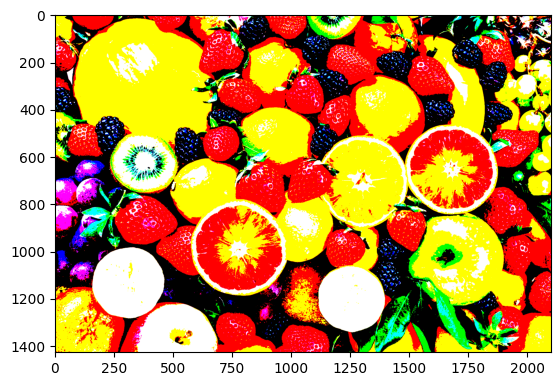

In [ ]:
#1 Phương pháp Otsu
data = Image.open('./exercise/fruit.jpg')
a = np.array(data)
thres = threshold_otsu(a)
b = a > thres
c = Image.fromarray((b * 255).astype(np.uint8))  # Convert boolean to uint8


plt.imshow(c)
plt.show()

In [ ]:
#2. Phương pháp Adaptive Thresholding
# data = Image.open('./exercise/fruit.jpg').convert('L')  # Convert to grayscale
# a = np.array(data)
# thres = threshold_otsu(a, 39, offset=0.1)  # The threshold_otsu() function from scikit-image automatically calculates the optimal threshold value and doesn't need additional parameters like nbins or offset.
# b = a > thres
# c = Image.fromarray((b * 255).astype(np.uint8))  # Convert boolean to uint8


# plt.imshow(c)
# plt.show()

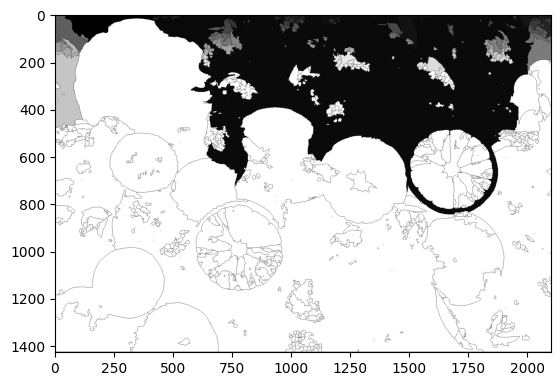

In [ ]:
#3 phân vùng theo region
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = cv2.imread('./exercise/fruit.jpg')
# converting image from color to grayscale
a = cv2.cvtColor(data, cv2.COLOR_BGR2GRAY)
# thresholding the image to obtain cell pixels
thresh, b1 = cv2.threshold(a, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
# since Otsu's method has over segmented the image
# erosion operation is performed
b2 = cv2.erode(b1, None, iterations = 2)
# distance transform is performed
dist_trans = cv2.distanceTransform(b2, 2, 3)
# thresholding the distance transform image to obtain
# pixels that are foreground
thresh, dt = cv2.threshold(dist_trans, 1, 255, cv2.THRESH_BINARY)
# performing labeling
labelled, ncc = label(dt)
# labelled is converted to 32-bit integer
labelled = labelled.astype(np.int32)
# performing watershed
cv2.watershed(data, labelled)
b = Image.fromarray(labelled)

plt.imshow(b)
plt.show()



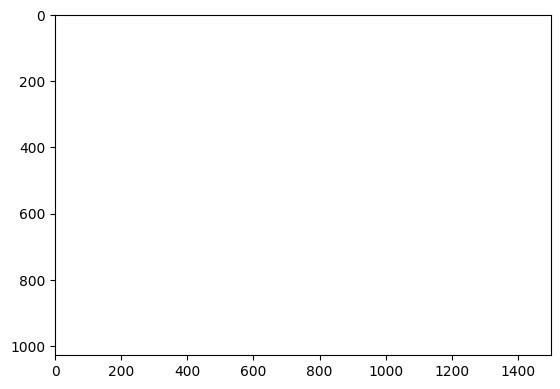

In [ ]:

#4 Biến đổi đối tượng trong ảnh - dùng binary dilation
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('./exercise/dalat.jpg').convert('L')
b = nd.binary_dilation(data, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


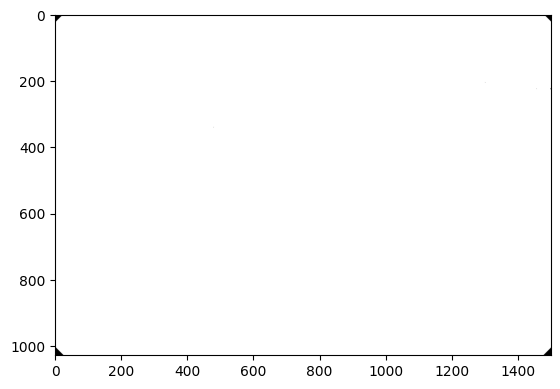

In [ ]:
#4 Biến đổi đối tượng trong ảnh - dùng binary opening
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('./exercise/dalat.jpg').convert('L')
# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_opening(data, structure=s, iterations=25)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


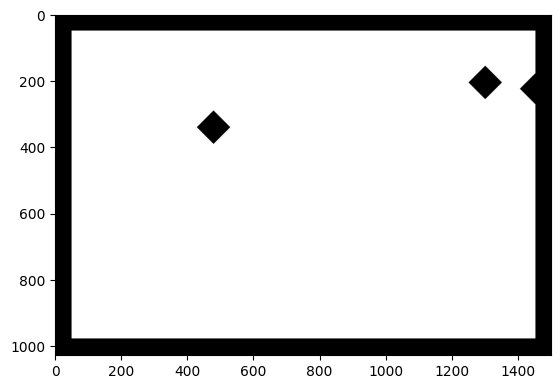

In [ ]:
#4 Biến đổi đối tượng trong ảnh - dùng binary erosion
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('./exercise/dalat.jpg').convert('L')
# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_erosion(data, structure=s, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()


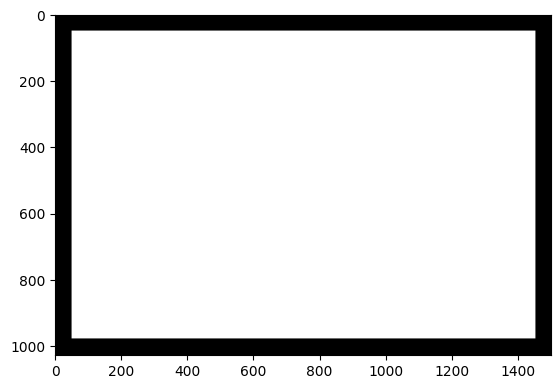

In [24]:
#4 Biến đổi đối tượng trong ảnh - dùng binary closing
import cv2
from PIL import Image
import numpy as np
import imageio.v2 as iio
import scipy.ndimage as nd
from scipy.ndimage import label
import matplotlib.pyplot as plt
from skimage.filters import threshold_local

# opening the image and converting it to grayscale
data = Image.open('./exercise/dalat.jpg').convert('L')
# defining the structuring element
s = [[0, 1, 0], [1, 1, 1], [0, 1, 0]]
b = nd.binary_closing(data, structure=s, iterations=50)

c = Image.fromarray(b)
c.show()
plt.imshow(c)
plt.show()